# Lab Assignment - 3

## Scikit-learn: Data Preprocessing and Model Performance Evaluation

### Part A - Data Loading and Preprocessing with Scikit-learn
#### Task 1 - Load and Understand the Dataset

In [46]:
import numpy as np #numerical arrays and mathematical operations
import pandas as pd #tables/DataFrames and data manipulation
import matplotlib.pyplot as plt # for customizing and displaying plots
import seaborn as sns # for statistical visualizations

In [47]:
df = pd.read_csv("hotel_bookings.csv")  #load the dataset
df.head() #display 5 top rows of the dataset


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [48]:
print("\nShape of dataset: ", df.shape) #shape of dataser(number of rows and col)

print("\nData types of dataset: ",df.dtypes) #the data types


Shape of dataset:  (119390, 32)

Data types of dataset:  hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type      

In [49]:
df.info #information about dataset

<bound method DataFrame.info of                hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27  

In [50]:
df.describe() #Summary statistics for numerical columns


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [51]:
#Check the class distribution of is_canceled and use it as the target y.
# is_canceled: 0 = not canceled, 1 = canceled
print(df["is_canceled"].value_counts())
print(df["is_canceled"].value_counts(normalize=True) * 100)  # as percentages

0    75166
1    44224
Name: is_canceled, dtype: int64
0    62.958372
1    37.041628
Name: is_canceled, dtype: float64


In [52]:
#Create X from the remaining usable features. Identify numerical and categorical columns.
#  target y 
y = df["is_canceled"]

#  X 
X = df.drop(columns=["is_canceled"])

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


#### Task 2 - Missing Values, Leakage, and Outliers

In [53]:
#Find the missing-value count and percentage for every column.
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent.round(2)
})

# Only show columns that actually have missing values, sorted descending
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing %", ascending=False)
print(missing_df)

          Missing Count  Missing %
company          112593      94.31
agent             16340      13.69
country             488       0.41
children              4       0.00


In [54]:
#  Step 2: Drop columns with very high missingness (justify with a comment) 
# Example logic (confirm against your printed missing_df before running):
# 'company' is often >90% missing — mostly NaN means "not booked via a company"
# Rather than drop it entirely, it's more informative to drop only if missingness is extreme
# and the column adds little predictive value. State your reasoning explicitly in the notebook.

high_missing_cols = missing_df[missing_df["Missing %"] > 90].index.tolist()
print("Columns with >90% missing:", high_missing_cols)

df = df.drop(columns=high_missing_cols)
X = X.drop(columns=[c for c in high_missing_cols if c in X.columns])

Columns with >90% missing: ['company']


In [55]:
#Step 3: Remove leakage columns 
# These columns are recorded AFTER the booking outcome is known — using them would leak
# the answer into the model (i.e., the model would "cheat").
leakage_cols = ["reservation_status", "reservation_status_date"]

X = X.drop(columns=[c for c in leakage_cols if c in X.columns])

print("Remaining columns after dropping leakage:", X.columns.tolist())

Remaining columns after dropping leakage: ['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


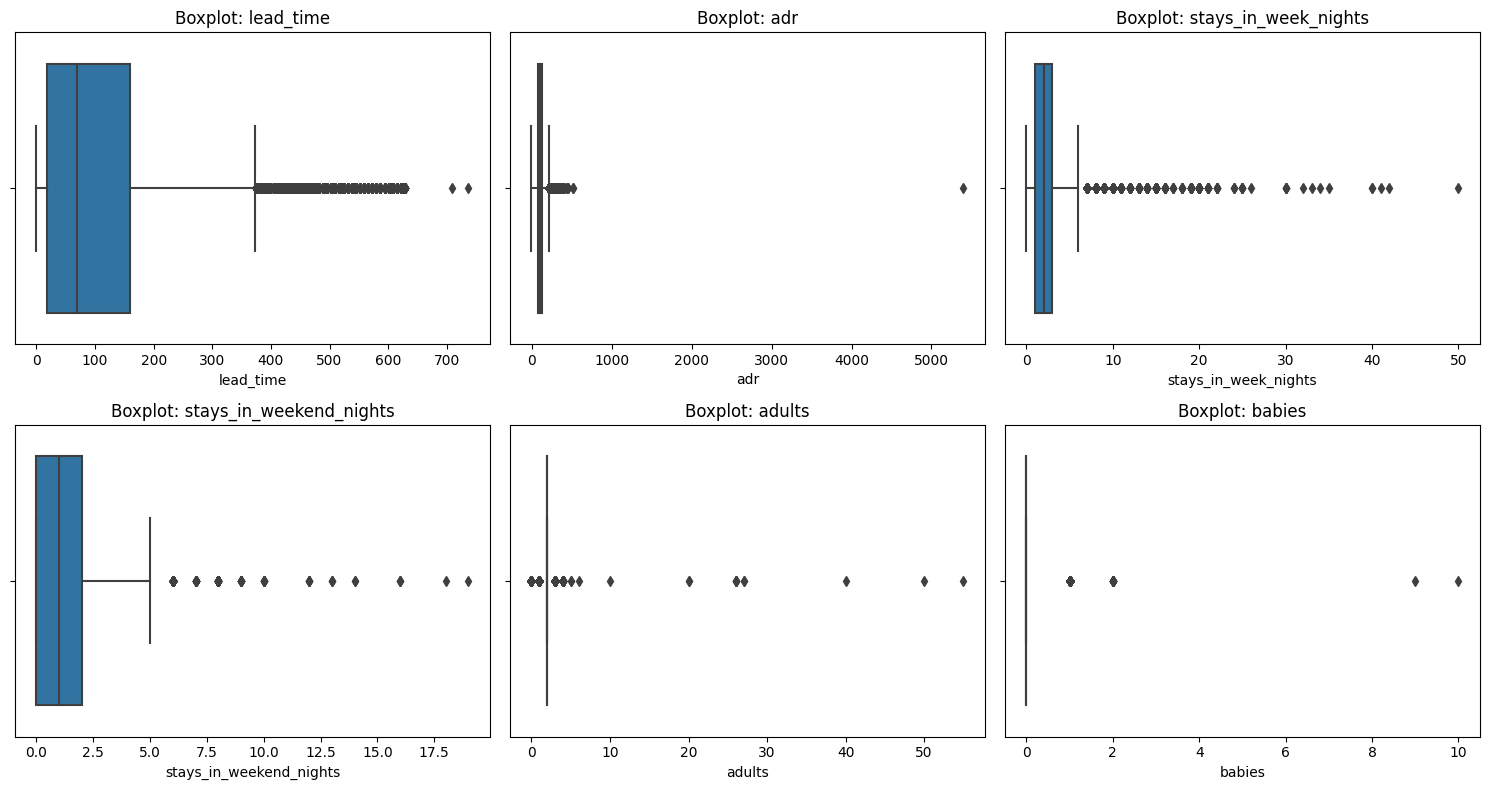

In [56]:
# Step 4: Check numerical features for outliers
# Focus on features known to have extreme values in this dataset
outlier_check_cols = ["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights", "adults", "babies"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_check_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

In [58]:
def count_iqr_outliers(data, column, factor=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return len(outliers), lower_bound, upper_bound


for col in ["adr", "lead_time", "stays_in_week_nights", "adults", "babies"]:
    count, lower, upper = count_iqr_outliers(df, col)

    print(f"\n{col}")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Potential outliers:", count)


adr
Lower bound: -7.124999999999986
Upper bound: 204.27499999999998
Potential outliers: 3122

lead_time
Lower bound: -194.5
Upper bound: 393.5
Potential outliers: 1925

stays_in_week_nights
Lower bound: -2.0
Upper bound: 6.0
Potential outliers: 1555

adults
Lower bound: 2.0
Upper bound: 2.0
Potential outliers: 0

babies
Lower bound: 0.0
Upper bound: 0.0
Potential outliers: 0
